# Customer Segmentation using K-Means Clustering

### Objective
The goal of this analysis is to segment customers into distinct groups based on their behavior and spending patterns using unsupervised learning techniques.

Techniques used:
- K-Means Clustering
- PCA (Principal Component Analysis)

### Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## 1. Data Loading and Preparation

In [2]:
df = pd.read_csv('../data/q2_customers.csv')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled[:5]

array([[-0.72521859, -0.17615043,  0.11016555, -0.26501121, -0.0899507 ,
         0.55095233],
       [-1.48846049, -1.04682639,  0.48615719, -0.9804657 , -0.83517593,
        -0.68068477],
       [ 0.17679458,  0.2673371 , -0.45382191, -0.23685064, -0.67404615,
        -0.27013907],
       [-0.72521859, -1.01230889,  0.29816137, -0.82778261, -0.99630571,
        -1.09123047],
       [-1.48846049, -1.03448783,  1.42613628, -1.00598621, -0.65390493,
        -1.50177617]])

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Feature scaling is essential for K-Means clustering because the algorithm is distance-based.  
If features are on different scales (e.g., annual spend vs visits), variables with larger values will dominate the distance calculation, leading to biased clustering results.

## 2. Choosing K — Elbow Method

In [4]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

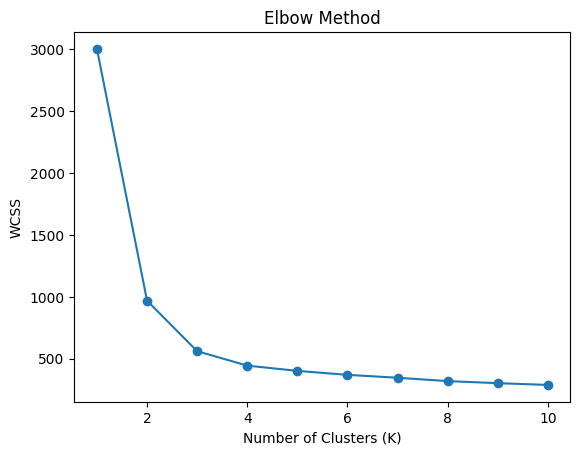

In [5]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

### Interpretation

From the elbow plot, the optimal number of clusters is K = 3.

This is because the reduction in WCSS slows significantly after K = 3, indicating diminishing returns from adding more clusters.

## 3. K-Means Clustering

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10,        # prevents hanging
    max_iter=300      # safety limit
)

clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

print(df.head())
print("\nCluster Distribution:")
print(df['cluster'].value_counts())

   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  cluster  
0                         6        2  
1                         3        0  
2                         4        2  
3                         2        0  
4                         1        0  

Cluster Distribution:
cluster
0    170
2    165
1    165
Name: count, dtype: int64


In [11]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation

- Cluster 0: High annual spend and frequent visits — represents loyal, high-value customers
- Cluster 1: Low spend and infrequent visits — represents low engagement customers
- Cluster 2: Moderate spend and visits — represents average customers

These segments can help the business design targeted marketing strategies.

## 4. PCA (Dimensionality Reduction)

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [9]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


## Interpretation
PC1 captures the majority of variation driven by spending-related features such as annual spend and basket size.

PC2 captures customer engagement behavior, including visit frequency and recency.

Together, these components help visualize customer segmentation effectively in two dimensions.

## 5. Cluster Visualization

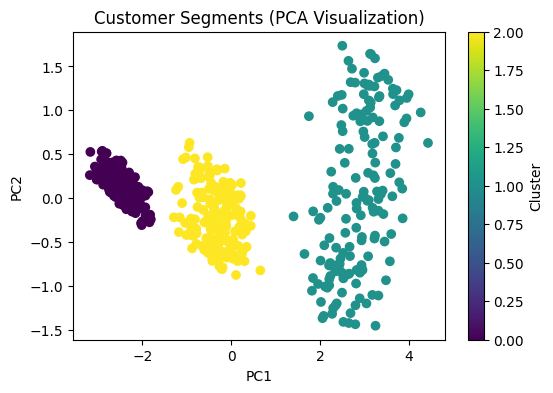

In [13]:
plt.figure(figsize=(6,4))

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments (PCA Visualization)")

plt.colorbar(label='Cluster')
plt.show()

The scatter plot visualizes customer segments in two dimensions.  
Distinct clusters indicate successful segmentation, while overlapping areas may suggest similar customer behaviors.